# J-lens fit convergence and confidence intervals — GPT-2 XL

Two questions about the J-lens fitted in `jacobian_logit_lens_dataset.ipynb`
(`FIT_MIX × 0.25` = 134 prompts, `max_seq_len=128`, fp32):

1. **Is 134 fit prompts enough?** Do the dataset metrics still move when prompts are added?
2. **How wide are the confidence intervals** of those metrics, and which source of noise
   dominates — the choice of fit prompts or the finite evaluation sets?

**Answer (this run, §6).** 134 prompts are enough. For inner pass@10 of intermediates the
fit-corpus spread (sd 0.004–0.022) and the bias left at finite N (≤ 0.009) are 2–5× below the
eval-set spread (sd 0.018–0.050): confidence intervals are set by the evaluation sets, and
refitting on more prompts would not change the conclusions.

## Method

The lens is linear in J: `J_S h = mean_{p∈S} J_p h`. While fitting we keep, for every fit
prompt p, its *transported readout* `T_p = H · J_pᵀ`: the eval-set block outputs at the readout
positions (551 items × 47 inner layers × 1600) mapped by that prompt's own Jacobian, 83 MB in
fp16. The lens fitted on any subset S of prompts reads the eval set as `mean_{p∈S} T_p`, so
learning curves, bootstraps, and split halves need no refitting — only `unembed` and ranks
(`jlens.readout_cache`).

| Source | What varies | Estimate |
|---|---|---|
| fit corpus | which prompts the lens is fitted on | source-stratified bootstrap of the fit prompts (B=200); 50 random disjoint halves, `sd(N) ≈ sd(half₁ − half₂) / 2` |
| convergence | whether adding prompts moves the metrics | curves over N in the original order and in 30 random orders; bias `mean(halves) − full`, the bias left at N if it scales as 1/N |
| eval set | which items the evaluation sets contain | item bootstrap within each dataset (B=2000), paired J-lens vs logit lens |

Readout and metrics follow `jacobian_logit_lens_dataset.ipynb`. *Inner* = best rank over
layers 0..46 (the model-output row excluded); inner pass@k of a dataset = mean over items of
the share of the item's words with inner rank ≤ k.

Every expensive step is cached in `RUN_DIR` and skipped when its output exists; the tracked fit
of 134 prompts takes ~2.5 h on a V100 (~64 s per prompt; fp16 autocast is 2.8× faster but
changes J by ~1e-3, TF32 is unavailable on Volta).

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "readout_cache.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from IPython.display import display
from tqdm.auto import tqdm

import jlens
from gpt2 import GPT2LensModel
from jlens.evaluation import (
    DATASETS,
    FIT_MIX,
    evaluate_paired,
    load_eval,
    load_fit_prompts,
    pass_at_k,
)
from jlens.fitting import jacobian_for_prompt
from jlens.readout_cache import (
    READOUT_CACHE_VERSION,
    ReadoutCache,
    WordRanker,
    build_readout_cache,
    item_scores,
    words_frame,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Cached artifacts; T files take ~11 GB for the 134 snapshot prompts.
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / "gpt2-xl-convergence"))
SNAPSHOT_LENS = RUN_DIR / "snapshot_lens_134.pt"  # JacobianLens.save output of jacobian_logit_lens_dataset.ipynb
SNAPSHOT_FRACTION, EXTENDED_FRACTION = 0.25, 1.0  # the snapshot corpus is a prefix of the extended one
FIT_STOP = 134  # prompts to fit with tracking; > 134 extends past the snapshot corpus
INCLUDE_EXTENSION = False  # also evaluate fitted extension prompts (saved in groups)
DIM_BATCH, MAX_SEQ_LEN, EXTENSION_GROUP = 8, 128, 16
N_PERMS, N_BOOT, N_HALVES, ITEM_BOOT = 30, 200, 50, 2000
K = 10
RUN_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)
print(RUN_DIR, DEVICE)

/workspace/runs/ci cuda


In [4]:
_model = None


def get_model() -> GPT2LensModel:
    """GPT-2 XL, loaded only by steps whose cached output is missing."""
    global _model
    if _model is None:
        _model = GPT2LensModel.from_pretrained(MODEL_ID, device=DEVICE)
    return _model


def load_unembed() -> torch.nn.Module:
    """``ln_f`` followed by ``lm_head``: the map of ``GPT2LensModel.unembed``."""
    hf = transformers.GPT2LMHeadModel.from_pretrained(MODEL_ID)
    head = torch.nn.Sequential(hf.transformer.ln_f, hf.lm_head).to(DEVICE).eval()
    return head.requires_grad_(False)


unembed = load_unembed()

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

## 1. Fit prompts

`load_fit_prompts` takes the first qualifying records of every source, so the 134-prompt
snapshot corpus is a per-source prefix of the full `FIT_MIX` corpus (the seed only shuffles
the order). The list keeps the snapshot prompts in their original order, then the extension.

In [5]:
def build_prompt_list(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_json(path, orient="records", lines=True)

    def mix(fraction):
        return {source: max(1, round(n * fraction)) for source, n in FIT_MIX.items()}

    snapshot = load_fit_prompts(mix(SNAPSHOT_FRACTION), seed=0).assign(part="snapshot")
    full = load_fit_prompts(mix(EXTENDED_FRACTION), seed=0)
    assert set(snapshot.text) <= set(full.text), "the snapshot corpus must be a prefix of the larger one"
    extension = full[~full.text.isin(set(snapshot.text))].assign(part="extension")
    prompts = pd.concat([snapshot, extension], ignore_index=True)
    prompts.to_json(path, orient="records", lines=True, force_ascii=False)
    return prompts


prompts = build_prompt_list(RUN_DIR / "prompts.jsonl")
N_SNAPSHOT = int((prompts.part == "snapshot").sum())
prompts.groupby(["source", "part"]).size().unstack("part")

part,extension,snapshot
source,,
code,30,10
dialogue,45,15
fiction,45,15
french,11,4
german,11,4
math,45,15
poetry,29,10
portuguese,11,4
spanish,11,4


## 2. Readout cache, checked against `evaluate_paired`

One forward pass per eval item caches the block outputs at the readout position. Ranks read
from the cache must reproduce the notebook evaluator.

Target IDs and derived rank/result caches are scoring-versioned: old prefix-answer results
are not reused. Unsupported targets retain null ranks and are excluded from score denominators.
Saved outputs below are historical; rerun to refresh them under this policy.

In [6]:
evals = {dataset: load_eval(REPO_DIR, dataset) for dataset in DATASETS}
cache_path = RUN_DIR / f"eval_cache_v{READOUT_CACHE_VERSION}.pt"
if cache_path.exists():
    cache = ReadoutCache.load(cache_path)
else:
    cache = build_readout_cache(get_model(), evals)
    cache.save(cache_path)
H, words = cache.H, cache.words
N_INNER = H.shape[1] - 1
ranker = WordRanker(words, DEVICE)
snapshot = jlens.JacobianLens.load(str(SNAPSHOT_LENS))
print(f"H {tuple(H.shape)}, {len(words)} ranked words, snapshot lens: {snapshot}")


def lens_ranks(jacobians=None) -> np.ndarray:
    """Ranks [n_words, n_layers] of a lens {layer: J}; None is the logit lens."""
    inner = torch.stack([H[:, layer] if jacobians is None else H[:, layer] @ jacobians[layer].float().T
                         for layer in range(N_INNER)])
    ranks = ranker.rank_residuals(unembed, inner)
    final = ranker.rank_residuals(unembed, H[None, :, -1])
    return np.concatenate([ranks, final]).T


R_snapshot = lens_ranks(snapshot.jacobians)
R_logit = lens_ranks()

H (551, 48, 1600), 2093 ranked words, snapshot lens: JacobianLens(d_model=1600, n_prompts=134, source_layers=[0..46] (47 layers))


In [7]:
baseline_path = RUN_DIR / f"baseline_words_v{READOUT_CACHE_VERSION}.pkl"
if baseline_path.exists():
    reference = pd.read_pickle(baseline_path)
else:
    reference, _ = evaluate_paired(get_model(), snapshot, evals)
    reference.to_pickle(baseline_path)


def inner_pass(frame, k=K):
    return pass_at_k(frame.drop(columns="lens", errors="ignore"), ks=[k], layers=slice(None, -1)).set_index(
        ["dataset", "kind"]).score


rows = []
for name, ranks in (("J-lens", R_snapshot), ("logit lens", R_logit)):
    expected = reference[reference.lens == name].reset_index(drop=True)
    supported = expected.ranks.notna().to_numpy()
    assert np.array_equal(supported, np.isfinite(ranks).all(axis=1))
    a = np.stack(expected.loc[supported, "ranks"]) if supported.any() else np.empty((0, ranks.shape[1]))
    scored_ranks = ranks[supported]
    rows.append({
        "lens": name,
        "scored words": int(supported.sum()),
        "unsupported words": int((~supported).sum()),
        "exact rank match": np.mean(a == scored_ranks) if a.size else np.nan,
        "max |log10 rank diff|": np.abs(np.log10(a) - np.log10(scored_ranks)).max() if a.size else np.nan,
        f"max |inner pass@{K} diff|": (inner_pass(expected) - inner_pass(words_frame(words, ranks))).abs().max(),
    })
pd.DataFrame(rows).set_index("lens").round(4)

,exact rank match,max |log10 rank diff|,max |inner pass@10 diff|
lens,,,
J-lens,0.9940,0.0158,0.0
logit lens,0.9964,0.0081,0.0


Rank differences come only from float rounding of differently shaped matrix products;
pass@k is identical.

## 3. Tracked fit

Fits prompts `[0, FIT_STOP)` with `jacobian_for_prompt` (the `jlens.fit` estimator) and saves,
per snapshot prompt or per group of `EXTENSION_GROUP` extension prompts, the summed `T` and
the prompt count. A running J sum makes the fit resumable and gives the fitted lens itself.

In [8]:
T_DIR = RUN_DIR / "T"
STATE_PATH = RUN_DIR / "jsum.pt"


def unit_files():
    """(prompt indices, T file) per unit: one per snapshot prompt, then extension groups."""
    units = [[idx] for idx in range(N_SNAPSHOT)]
    units += [list(range(start, min(start + EXTENSION_GROUP, len(prompts))))
              for start in range(N_SNAPSHOT, len(prompts), EXTENSION_GROUP)]
    return [(unit, T_DIR / (f"p{unit[0]:04}.pt" if unit[0] < N_SNAPSHOT else f"g{unit[0]:04}-{unit[-1]:04}.pt"))
            for unit in units]


def fit_transported(stop: int) -> None:
    model = get_model()
    layers = list(range(model.n_layers - 1))
    H_device = H.to(DEVICE)
    T_DIR.mkdir(exist_ok=True)
    if STATE_PATH.exists():
        state = torch.load(STATE_PATH, weights_only=True)
        jsum, n_fit, done_idx = state["jsum"], state["n_fit"], state["done_idx"]
    else:
        jsum = {layer: torch.zeros(model.d_model, model.d_model) for layer in layers}
        n_fit, done_idx = 0, 0
    todo = [(unit, path) for unit, path in unit_files() if unit[-1] >= done_idx and unit[0] < stop]
    for unit, path in tqdm(todo, desc="tracked fit", unit="file"):
        T_sum = torch.zeros(len(layers), H.shape[0], model.d_model, device=DEVICE)
        unit_jsum = {layer: torch.zeros_like(jsum[layer]) for layer in layers}
        meta = []
        for idx in unit:
            started = time.perf_counter()
            try:
                J, seq_len, n_valid = jacobian_for_prompt(
                    model, prompts.text[idx], layers, dim_batch=DIM_BATCH, max_seq_len=MAX_SEQ_LEN)
            except ValueError:  # too short to have valid positions
                continue
            for layer in layers:
                T_sum[layer] += H_device[:, layer] @ J[layer].to(DEVICE).T
                unit_jsum[layer] += J[layer]
            meta.append({"idx": idx, "source": prompts.source[idx], "seq_len": seq_len,
                         "n_valid": n_valid, "seconds": time.perf_counter() - started})
        tmp = path.with_suffix(".tmp")
        torch.save({"T_sum": T_sum.half().cpu(), "n": len(meta), "meta": meta}, tmp)
        tmp.replace(path)
        for layer in layers:
            jsum[layer] += unit_jsum[layer]
        n_fit, done_idx = n_fit + len(meta), unit[-1] + 1
        tmp = STATE_PATH.with_suffix(".tmp")
        torch.save({"jsum": jsum, "n_fit": n_fit, "done_idx": done_idx}, tmp)
        tmp.replace(STATE_PATH)
    lens = jlens.JacobianLens({layer: jsum[layer] / n_fit for layer in layers}, n_prompts=n_fit,
                              d_model=model.d_model)
    lens.save(str(RUN_DIR / f"lens_n{n_fit}.pt"))


done = torch.load(STATE_PATH, weights_only=True)["done_idx"] if STATE_PATH.exists() else 0
if done < FIT_STOP:
    fit_transported(FIT_STOP)
else:
    print(f"The tracked fit already covers prompts [0, {done}); FIT_STOP = {FIT_STOP}.")

The tracked fit already covers prompts [0, 166); FIT_STOP = 134.


## 4. Lenses over subsets of the fit prompts

Each lens is a weight vector over the saved units; its readout is
`Σ_u w_u T_u / Σ_u w_u n_u`.

| `experiment` | lenses |
|---|---|
| `order` | cumulative mean in the original fit order, N = 1..134 |
| `perm` | cumulative means in 30 random orders, N ∈ {4, 8, 16, …, 134} |
| `boot` | 200 source-stratified bootstrap resamples of the 134 prompts |
| `half` | 50 random splits into disjoint halves of 67, both halves kept |
| `ext`, `ext_only` | snapshot + extension groups, extension only (with `INCLUDE_EXTENSION`) |

In [9]:
units = [(unit, path) for unit, path in unit_files()
         if path.exists() and (INCLUDE_EXTENSION or unit[0] < N_SNAPSHOT)]
n_unit = np.array([len(unit) for unit, _ in units], dtype=float)
unit_source = np.array([prompts.source[unit[0]] for unit, _ in units])
snap = np.flatnonzero([unit[0] < N_SNAPSHOT for unit, _ in units])
ext = np.flatnonzero([unit[0] >= N_SNAPSHOT for unit, _ in units])

lenses = []


def add(experiment, rep, chosen):
    w = np.zeros(len(units))
    np.add.at(w, chosen, 1.0)
    lenses.append({"experiment": experiment, "N": int(w @ n_unit), "rep": rep, "w": w})


for n in range(1, len(snap) + 1):
    add("order", 0, snap[:n])
for rep in range(N_PERMS):
    order = rng.permutation(snap)
    for n in (4, 8, 16, 24, 32, 48, 64, 80, 96, 112, 134):
        if n <= len(snap):
            add("perm", rep, order[:n])
by_source = [snap[unit_source[snap] == source] for source in np.unique(unit_source[snap])]
for rep in range(N_BOOT):
    add("boot", rep, np.concatenate([rng.choice(idx, len(idx)) for idx in by_source]))
for rep in range(N_HALVES):
    order = rng.permutation(snap)
    add("half", 2 * rep, order[: len(snap) // 2])
    add("half", 2 * rep + 1, order[len(snap) // 2:])
for g in range(1, len(ext) + 1):
    add("ext", 0, np.concatenate([snap, ext[:g]]))
    add("ext_only", 0, ext[:g])
lens_meta = pd.DataFrame([{key: value for key, value in lens.items() if key != "w"} for lens in lenses])
W = torch.tensor(np.stack([lens["w"] for lens in lenses]), dtype=torch.float32)
W = W / (W @ torch.tensor(n_unit, dtype=torch.float32))[:, None]
lens_meta.groupby("experiment").size()

experiment
boot     200
half     100
order    134
perm     330
dtype: int64

In [10]:
ranks_path = RUN_DIR / f"ranks_lenses_v{READOUT_CACHE_VERSION}.npy"
meta_path = RUN_DIR / f"lenses_meta_v{READOUT_CACHE_VERSION}.parquet"
cached = meta_path.exists() and ranks_path.exists() and pd.read_parquet(meta_path).reset_index(drop=True).equals(lens_meta)
if cached:
    R_lenses = np.load(ranks_path)
else:
    saved = [torch.load(path, weights_only=False) for _, path in units]
    assert [item["n"] for item in saved] == n_unit.astype(int).tolist(), "a fit prompt was skipped"
    T = torch.stack([item["T_sum"] for item in saved])  # [units, n_inner, n_items, d] fp16
    del saved
    R_lenses = np.full((len(lenses), len(words), N_INNER + 1), np.nan, dtype=np.float64)
    for layer in tqdm(range(N_INNER), desc="layers"):
        T_layer = T[:, layer].to(DEVICE).float()
        for start in range(0, len(lenses), 64):
            mixed = torch.einsum("bu,uid->bid", W[start:start + 64].to(DEVICE), T_layer)
            R_lenses[start:start + 64, :, layer] = ranker.rank_residuals(unembed, mixed)
        del T_layer
    R_lenses[:, :, -1] = R_snapshot[:, -1]
    del T
    np.save(ranks_path, R_lenses)
    lens_meta.to_parquet(meta_path)
print(f"{len(lenses)} lenses, ranks {R_lenses.shape}, {'loaded' if cached else 'computed'}")

764 lenses, ranks (764, 2093, 48), loaded


**Reproduction.** The refit of the 134 snapshot prompts must match the saved snapshot lens:

In [11]:
refit = R_lenses[lens_meta.index[(lens_meta.experiment == "order") & (lens_meta.N == N_SNAPSHOT)][0]]
print("max |log10 rank diff| refit vs snapshot:", np.abs(np.log10(refit) - np.log10(R_snapshot)).max().round(4))
pd.DataFrame({f"refit, inner pass@{K}": inner_pass(words_frame(words, refit)),
              f"snapshot, inner pass@{K}": inner_pass(words_frame(words, R_snapshot))}).round(4).T

max |log10 rank diff| refit vs snapshot: 0.1761


dataset                 association              multihop                      multilingual                      order-ops                       poetry                 typo             
kind                        control intermediate  control intermediate  target      control intermediate  target   control intermediate  target control intermediate control intermediate
refit, inner pass@10         0.0098        0.049   0.0217       0.2796  0.3871       0.0093       0.1565  0.1776      0.47       0.7091  0.6909     0.0          0.0     0.0       0.4062
snapshot, inner pass@10      0.0098        0.049   0.0217       0.2796  0.3871       0.0093       0.1565  0.1776      0.47       0.7091  0.6909     0.0          0.0     0.0       0.4062

T is stored in fp16: deep ranks shift slightly (at most 0.18 in log10) and pass@k is unchanged.

## 5. Scores

In [12]:
METRICS = {"inner pass@1": 1, "inner pass@10": 10, "inner pass@100": 100, "mean log10 inner rank": None}
KINDS = ("intermediate", "control", "target")


def supported_mean(x, axis=None):
    """Finite-only mean; zero support is undefined, without empty-slice warnings."""
    x = np.asarray(x)
    valid = np.isfinite(x)
    count = valid.sum(axis=axis)
    with np.errstate(divide="ignore", invalid="ignore"):
        result = np.where(count > 0, np.where(valid, x, 0).sum(axis=axis) / count, np.nan)
    return result[()] if result.ndim == 0 else result


def supported_sd(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    return x.std(ddof=1) if x.size > 1 else np.nan


def supported_percentile(x, q):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    return np.percentile(x, q) if x.size else np.nan


def target_coverage(dataset):
    """Tokenizer support: target words and items with at least one supported target."""
    dataset_words = words[words.dataset == dataset]
    targets = dataset_words[dataset_words.kind == "target"]
    supported = targets[targets.ids.map(len) > 0]
    return {
        "n_targets_total": len(targets),
        "n_targets_supported": len(supported),
        "n_items_total": dataset_words.item_index.nunique(),
        "n_target_items_supported": supported.item_index.nunique(),
    }


def score_frame(ranks: np.ndarray, meta: pd.DataFrame) -> pd.DataFrame:
    """Long frame of every metric for ranks [n_lenses, n_words, n_layers]."""
    frames = []
    for dataset in DATASETS:
        for kind in KINDS:
            if not ((words.dataset == dataset) & (words.kind == kind)).any():
                continue
            for metric, k in METRICS.items():
                items = item_scores(words, ranks, dataset, kind, k=k)
                frames.append(meta.assign(
                    dataset=dataset, kind=kind, metric=metric, value=supported_mean(items, axis=-1),
                    n_score_items_supported=np.isfinite(items).sum(axis=-1),
                    **target_coverage(dataset),
                ))
    return pd.concat(frames, ignore_index=True)


curves = pd.concat([
    score_frame(R_lenses, lens_meta),
    score_frame(R_snapshot[None], pd.DataFrame({"experiment": ["snapshot"], "N": [N_SNAPSHOT], "rep": [0]})),
    score_frame(R_logit[None], pd.DataFrame({"experiment": ["logit"], "N": [0], "rep": [0]})),
], ignore_index=True)


def values(experiment, dataset, kind, metric, N=None) -> pd.DataFrame:
    sel = curves[(curves.experiment == experiment) & (curves.dataset == dataset)
                 & (curves.kind == kind) & (curves.metric == metric)]
    return sel if N is None else sel[sel.N == N]


def eval_bootstrap(kind, k):
    """Paired draws, support count, and exact mean difference on jointly finite items."""
    out = {}
    for dataset in DATASETS:
        if not ((words.dataset == dataset) & (words.kind == kind)).any():
            continue
        J_items = item_scores(words, R_snapshot, dataset, kind, k=k)
        L_items = item_scores(words, R_logit, dataset, kind, k=k)
        supported = np.isfinite(J_items) & np.isfinite(L_items)
        n = int(supported.sum())
        if n == 0:
            out[dataset] = (np.full(ITEM_BOOT, np.nan), np.full(ITEM_BOOT, np.nan), 0, np.nan)
            continue
        J_items, L_items = J_items[supported], L_items[supported]
        draws = rng.integers(0, n, size=(ITEM_BOOT, n))
        out[dataset] = (J_items[draws].mean(1), L_items[draws].mean(1), n, (J_items - L_items).mean())
    return out


rows = []
for metric, k in METRICS.items():
    for kind in KINDS:
        boot_eval = eval_bootstrap(kind, k)
        for dataset, (J_eval, L_eval, n_paired, paired_difference) in boot_eval.items():
            full = values("order", dataset, kind, metric, N_SNAPSHOT).value.iloc[0]
            snap_value = values("snapshot", dataset, kind, metric).value.iloc[0]
            logit = values("logit", dataset, kind, metric).value.iloc[0]
            boot = values("boot", dataset, kind, metric).value.values
            half = values("half", dataset, kind, metric).sort_values("rep").value.values
            perm = values("perm", dataset, kind, metric)
            moves = {f"|N{n} − N{N_SNAPSHOT}|": supported_mean(np.abs(perm[perm.N == n].value.values - full))
                     for n in (32, 64, 96, 112)}
            rows.append({
                "metric": metric, "kind": kind, "dataset": dataset,
                **target_coverage(dataset),
                "n_score_items_supported": values("snapshot", dataset, kind, metric).n_score_items_supported.iloc[0],
                "n_paired_items_supported": n_paired,
                "J-lens": snap_value, "logit lens": logit,
                "fit sd (boot)": supported_sd(boot),
                "fit CI lo": supported_percentile(boot, 2.5), "fit CI hi": supported_percentile(boot, 97.5),
                "fit sd (halves)": supported_sd(half[0::2] - half[1::2]) / 2,
                "N/2 bias": supported_mean(half) - full,
                **moves,
                "eval sd": supported_sd(J_eval),
                "eval CI lo": supported_percentile(J_eval, 2.5), "eval CI hi": supported_percentile(J_eval, 97.5),
                "J − logit": paired_difference,
                "J − logit CI lo": supported_percentile(J_eval - L_eval, 2.5),
                "J − logit CI hi": supported_percentile(J_eval - L_eval, 97.5),
            })
summary = pd.DataFrame(rows)
with np.errstate(divide="ignore", invalid="ignore"):
    summary["fit sd / eval sd"] = summary["fit sd (boot)"] / summary["eval sd"]
summary.to_csv(RUN_DIR / "summary.csv", index=False)


def show(metric, kind="intermediate", columns=None):
    table = summary[(summary.metric == metric) & (summary.kind == kind)].set_index("dataset")
    table = table.drop(columns=["metric", "kind"]) if columns is None else table[columns]
    return table.T.round(3)

## 6. Results

### 6.1 Inner pass@10 of intermediates

`fit …` columns: spread over fit corpora at N = 134. `|Nn − N134|`: mean change between a
random N-prompt lens and the 134-prompt lens over random orders. `eval …`: item bootstrap of
the evaluation set, restricted to items with finite scores for both lenses. Zero paired support
produces undefined (NaN) estimates and intervals, not misses. `J − logit CI`: paired item bootstrap.
All score rows and exported `summary.csv` rows include per-dataset `n_targets_supported` /
`n_targets_total` and `n_target_items_supported` / `n_items_total` (complete-token target support,
with at least one supported target per supported item). `n_score_items_supported` counts finite
items for the row's word kind; `n_paired_items_supported` counts the joint bootstrap population.
Intermediate/control prefix probes can be supported even when an item's target is unsupported.

In [13]:
show(f"inner pass@{K}")

dataset,multihop,multilingual,order-ops,poetry,association,typo
J-lens,0.280,0.157,0.709,0.000,0.049,0.406
logit lens,0.280,0.185,0.582,0.010,0.039,0.323
fit sd (boot),0.009,0.004,0.022,0.000,0.007,0.009
fit CI lo,0.258,0.152,0.672,0.000,0.029,0.396
fit CI hi,0.290,0.166,0.755,0.000,0.049,0.427
fit sd (halves),0.008,0.005,0.022,0.000,0.007,0.013
N/2 bias,-0.005,0.003,0.002,0.000,-0.009,0.007
|N32 − N134|,0.008,0.005,0.030,0.001,0.012,0.019
|N64 − N134|,0.008,0.004,0.019,0.000,0.008,0.012
|N96 − N134|,0.007,0.004,0.012,0.000,0.005,0.003


### 6.2 Mean log10 inner rank and inner pass@100 of intermediates

A continuous metric (no threshold) and a looser one.

In [14]:
columns = ["J-lens", "fit sd (boot)", "fit sd (halves)", "N/2 bias", f"|N64 − N{N_SNAPSHOT}|",
           f"|N112 − N{N_SNAPSHOT}|", "eval sd", "fit sd / eval sd"]
display(show("mean log10 inner rank", columns=columns))
display(show("inner pass@100", columns=columns))

dataset,multihop,multilingual,order-ops,poetry,association,typo
J-lens,1.665,2.307,0.790,2.472,2.534,1.273
fit sd (boot),0.017,0.018,0.013,0.015,0.014,0.012
fit sd (halves),0.017,0.019,0.013,0.018,0.015,0.020
N/2 bias,0.000,-0.001,-0.002,-0.001,0.002,0.004
|N64 − N134|,0.011,0.015,0.014,0.015,0.015,0.018
|N112 − N134|,0.007,0.007,0.006,0.006,0.006,0.007
eval sd,0.094,0.052,0.037,0.056,0.071,0.100
fit sd / eval sd,0.179,0.342,0.358,0.268,0.193,0.120


dataset,multihop,multilingual,order-ops,poetry,association,typo
J-lens,0.579,0.299,1.0,0.255,0.167,0.729
fit sd (boot),0.027,0.010,0.0,0.015,0.011,0.007
fit sd (halves),0.025,0.009,0.0,0.014,0.010,0.011
N/2 bias,0.005,0.007,0.0,-0.019,0.013,-0.000
|N64 − N134|,0.025,0.009,0.0,0.023,0.014,0.010
|N112 − N134|,0.019,0.006,0.0,0.012,0.009,0.000
eval sd,0.052,0.020,0.0,0.044,0.038,0.046
fit sd / eval sd,0.517,0.488,NaN,0.345,0.295,0.157


### 6.3 Fit-corpus sd / eval-set sd, every metric and word kind

In [15]:
summary.pivot_table(index=["metric", "kind"], columns="dataset", values="fit sd / eval sd")[DATASETS].round(2)

dataset                             multihop  multilingual  order-ops  poetry  association  typo
metric                kind                                                                      
inner pass@1          control            NaN          0.00       0.52     NaN          NaN   NaN
                      intermediate      0.11          0.25       0.13     NaN         0.39  0.23
                      target            0.14          0.22       0.00     NaN          NaN   NaN
inner pass@10         control           0.00          0.66       0.35     NaN         0.15   NaN
                      intermediate      0.20          0.23       0.50     NaN         0.33  0.18
                      target            0.13          0.20       0.19     NaN          NaN   NaN
inner pass@100        control           0.52          0.82       0.00    0.46         0.35  0.27
                      intermediate      0.52          0.49        NaN    0.35         0.30  0.16
                      target            0.87          0.25        NaN     NaN          NaN   NaN
mean log10 inner rank control           0.28          0.66       0.28    0.35         0.27  0.25
                      intermediate      0.18          0.34       0.36    0.27         0.19  0.12
                      target            0.24          0.19       0.14     NaN          NaN   NaN

### 6.4 Learning curves

The band of random orders collapses at N = 134 by construction (every order ends with the same
set), so convergence to the infinite-corpus value is shown by the fit-corpus bootstrap interval
(point with whiskers) and the halves bias, not by the band.

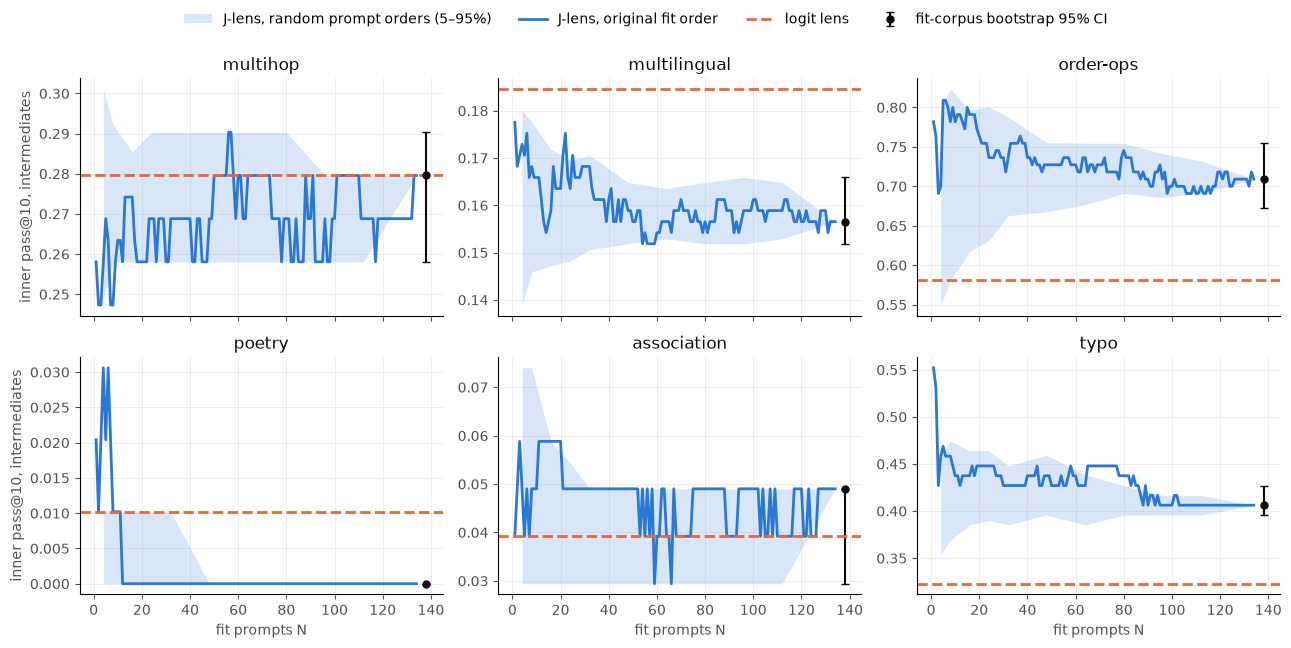

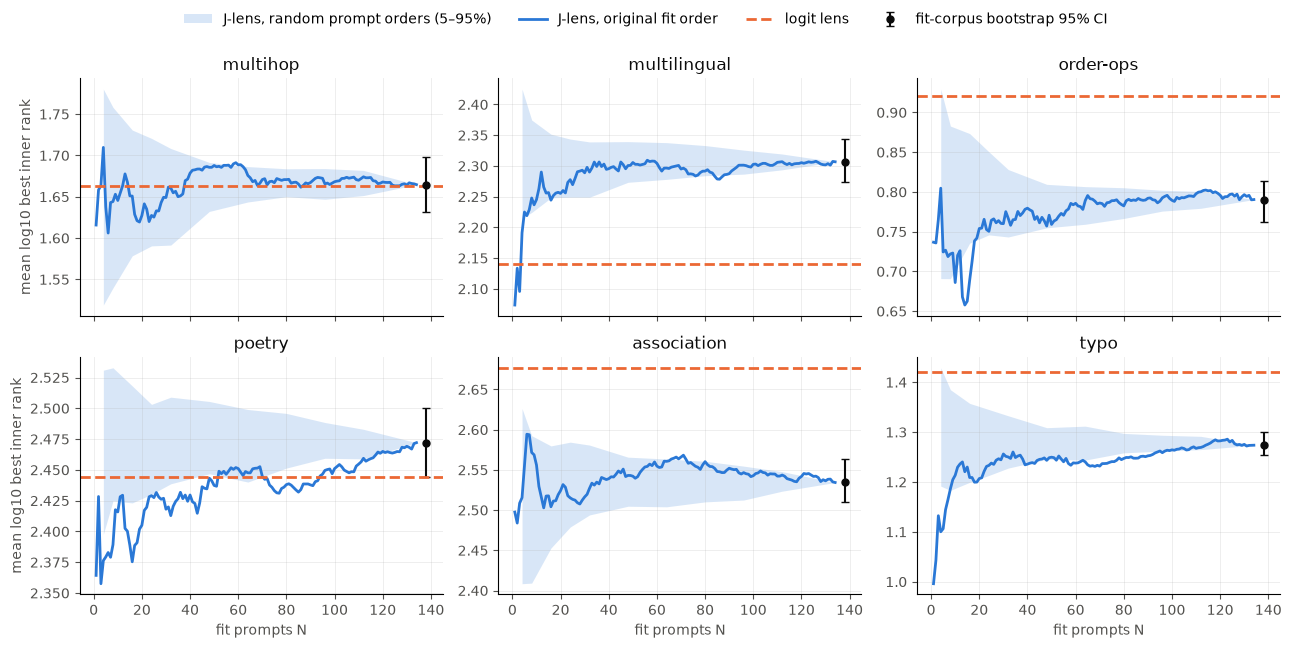

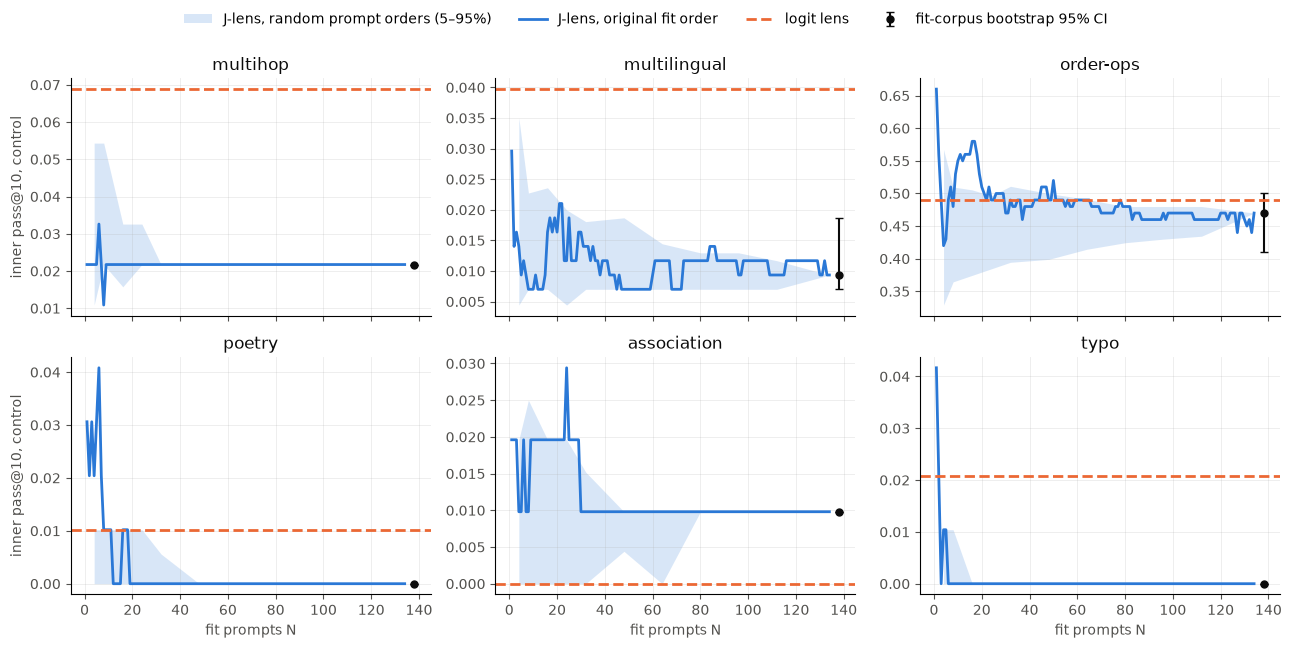

In [16]:
J_COLOR, LOGIT_COLOR, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"


def plot_curves(kind, metric, ylabel):
    fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)
    for ax, dataset in zip(axes.flat, DATASETS, strict=True):
        band = values("perm", dataset, kind, metric).groupby("N").value.quantile([0.05, 0.95]).unstack()
        ax.fill_between(band.index, band[0.05], band[0.95], color=J_COLOR, alpha=0.18, lw=0,
                        label="J-lens, random prompt orders (5–95%)")
        order = values("order", dataset, kind, metric).sort_values("N")
        ax.plot(order.N, order.value, color=J_COLOR, lw=2, label="J-lens, original fit order")
        boot = values("boot", dataset, kind, metric).value
        last = order.value.iloc[-1]
        ax.errorbar([N_SNAPSHOT + 4], [last], yerr=[[last - boot.quantile(0.025)], [boot.quantile(0.975) - last]],
                    fmt="o", ms=5, color=INK, capsize=3, lw=1.5, label="fit-corpus bootstrap 95% CI")
        ax.axhline(values("logit", dataset, kind, metric).value.iloc[0], color=LOGIT_COLOR, lw=2, ls="--",
                   label="logit lens")
        ax.set_title(dataset, color=INK)
        ax.grid(alpha=0.25, lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(colors=MUTED)
    for ax in axes[-1]:
        ax.set_xlabel("fit prompts N", color=MUTED)
    for ax in axes[:, 0]:
        ax.set_ylabel(ylabel, color=MUTED)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()


plot_curves("intermediate", f"inner pass@{K}", f"inner pass@{K}, intermediates")
plot_curves("intermediate", "mean log10 inner rank", "mean log10 best inner rank")
plot_curves("control", f"inner pass@{K}", f"inner pass@{K}, control")

## 7. Conclusions

* **Reproduction.** Refitting the 134 snapshot prompts reproduces the saved lens: the same J
  up to fp16 storage and identical pass@k.
* **Convergence.** Near N = 134 the metrics barely move (`|N112 − N134|` ≤ 0.010 in inner
  pass@10, ≤ 0.007 in mean log10 rank), and the bias left at N = 134, estimated from the halves,
  is ≤ 0.009 in pass@10 and ≤ 0.004 in log10 rank. Doubling the corpus would shrink the
  fit-corpus sd only by √2. **No further fitting is needed.**
* **Confidence intervals.** For intermediates the fit-corpus sd is 0.11–0.52 of the eval-set sd
  across metrics, so a total interval is at most ~13% wider than the eval-only one (order-ops
  pass@10, multihop pass@100) and usually 2–5% wider. The eval CIs in §6.1 are the relevant ones.
* **J-lens vs logit lens** (paired eval CI, inner pass@10): significantly better on order-ops
  (+0.127 [0.027, 0.227]) and typo (+0.083 [0.010, 0.167]), slightly worse on multilingual
  (−0.028 [−0.054, 0.000]); the rest is within noise. The typo and multilingual bounds move by
  ~0.01 between bootstrap seeds, so treat both as borderline.

**Limitations.** Only readout-position metrics (pass@k, ranks) are covered, not agreement /
copy rate / KL over all positions. The bootstrap varies prompts within the same sources and
`FIT_MIX`; sensitivity to the mix, `max_seq_len`, and `skip_first` is not tested. The direct
134 vs 529 prompt check was stopped at 166 prompts (`INCLUDE_EXTENSION` evaluates what exists).